In [1]:
# Install required library
!pip install requests beautifulsoup4

# Import libraries
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [3]:
# Step 1 - Fetch the webpage
url = "http://books.toscrape.com"
response = requests.get(url)

print("Status Code:", response.status_code)
print("Response Type:", type(response.text))
print("\nFirst 500 characters of HTML:")
print(response.text[:1000])

Status Code: 200
Response Type: <class 'str'>

First 500 characters of HTML:
<!DOCTYPE html>
<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->
<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->
<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->
<!--[if gt IE 8]><!--> <html lang="en-us" class="no-js"> <!--<![endif]-->
    <head>
        <title>
    All products | Books to Scrape - Sandbox
</title>

        <meta http-equiv="content-type" content="text/html; charset=UTF-8" />
        <meta name="created" content="24th Jun 2016 09:29" />
        <meta name="description" content="" />
        <meta name="viewport" content="width=device-width" />
        <meta name="robots" content="NOARCHIVE,NOCACHE" />

        <!-- Le HTML5 shim, for IE6-8 support of HTML elements -->
        <!--[if lt IE 9]>
        <script src="//html5shim.googlecode.com/svn/trunk/html5.js"></script>
        <![endif]--

In [4]:
# Step 2 - Parse the HTML with BeautifulSoup
soup = BeautifulSoup(response.text, 'html.parser')

# Find all books on the page
books = soup.find_all('article', class_='product_pod')

print("Number of books found:", len(books))
print("\nFirst book raw HTML:")
print(books[0])

Number of books found: 20

First book raw HTML:
<article class="product_pod">
<div class="image_container">
<a href="catalogue/a-light-in-the-attic_1000/index.html"><img alt="A Light in the Attic" class="thumbnail" src="media/cache/2c/da/2cdad67c44b002e7ead0cc35693c0e8b.jpg"/></a>
</div>
<p class="star-rating Three">
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
</p>
<h3><a href="catalogue/a-light-in-the-attic_1000/index.html" title="A Light in the Attic">A Light in the ...</a></h3>
<div class="product_price">
<p class="price_color">Â£51.77</p>
<p class="instock availability">
<i class="icon-ok"></i>
    
        In stock
    
</p>
<form>
<button class="btn btn-primary btn-block" data-loading-text="Adding..." type="submit">Add to basket</button>
</form>
</div>
</article>


In [5]:
#Step 3 - Fetching one book
first_book = books[0]

title = first_book.h3.a['title']

price = first_book.find('p' , class_='price_color').text

rating = first_book.find('p', class_='star-rating')['class'][1]

print("Title:", title)
print("Price:", price)
print("Rating:", rating)

Title: A Light in the Attic
Price: Â£51.77
Rating: Three


In [7]:
# Step 4 - Scrape all 50 books
all_books = []

for book in books:
    # Extract each piece of data
    title = book.h3.a['title']
    price = book.find('p', class_='price_color').text.replace('Â£', '£')
    rating = book.find('p', class_='star-rating')['class'][1]

    # Store as dictionary
    all_books.append({
        'Title': title,
        'Price': price,
        'Rating': rating
    })

# Convert to dataframe
df_books = pd.DataFrame(all_books)

print(f"Successfully scraped {len(df_books)} books")
print("\nFirst 5 results:")
df_books.head()

Successfully scraped 20 books

First 5 results:


,Title,Price,Rating
0,A Light in the Attic,£51.77,Three
1,Tipping the Velvet,£53.74,One
2,Soumission,£50.10,One
3,Sharp Objects,£47.82,Four
4,Sapiens: A Brief History of Humankind,£54.23,Five


In [8]:
# Step 5 - Scrape all 50 pages
all_books = []

for page in range(1, 51):
    # Build the URL for each page
    if page == 1:
        url = "http://books.toscrape.com"
    else:
        url = f"http://books.toscrape.com/catalogue/page-{page}.html"

    # Fetch the page
    response = requests.get(url)
    soup = BeautifulSoup(response.text, 'html.parser')
    books = soup.find_all('article', class_='product_pod')

    # Extract data from each book
    for book in books:
        title = book.h3.a['title']
        price = book.find('p', class_='price_color').text.replace('Â£', '£')
        rating = book.find('p', class_='star-rating')['class'][1]

        all_books.append({
            'Title': title,
            'Price': price,
            'Rating': rating
        })

    # Be polite - don't hammer the server
    time.sleep(0.5)

    # Progress update
    print(f"Scraped page {page}/50 - Total books so far: {len(all_books)}")

print(f"\nDone! Total books scraped: {len(all_books)}")

Scraped page 1/50 - Total books so far: 20
Scraped page 2/50 - Total books so far: 40
Scraped page 3/50 - Total books so far: 60
Scraped page 4/50 - Total books so far: 80
Scraped page 5/50 - Total books so far: 100
Scraped page 6/50 - Total books so far: 120
Scraped page 7/50 - Total books so far: 140
Scraped page 8/50 - Total books so far: 160
Scraped page 9/50 - Total books so far: 180
Scraped page 10/50 - Total books so far: 200
Scraped page 11/50 - Total books so far: 220
Scraped page 12/50 - Total books so far: 240
Scraped page 13/50 - Total books so far: 260
Scraped page 14/50 - Total books so far: 280
Scraped page 15/50 - Total books so far: 300
Scraped page 16/50 - Total books so far: 320
Scraped page 17/50 - Total books so far: 340
Scraped page 18/50 - Total books so far: 360
Scraped page 19/50 - Total books so far: 380
Scraped page 20/50 - Total books so far: 400
Scraped page 21/50 - Total books so far: 420
Scraped page 22/50 - Total books so far: 440
Scraped page 23/50 - To

In [9]:
# Convert rating words to numbers
rating_map = {
    'One': 1, 'Two': 2, 'Three': 3,
    'Four': 4, 'Five': 5
}

df_books = pd.DataFrame(all_books)
df_books['Rating_Numeric'] = df_books['Rating'].map(rating_map)
df_books['Price_Clean'] = df_books['Price'].str.replace('£', '').astype(float)

# Save to CSV
df_books.to_csv('books_data.csv', index=False)

print(f"Dataset saved successfully!")
print(f"Total Books: {len(df_books)}")
print(f"\nSample Data:")
print(df_books.head())
print(f"\nAverage Price: £{df_books['Price_Clean'].mean():.2f}")
print(f"Most Common Rating: {df_books['Rating'].value_counts().index[0]}")

Dataset saved successfully!
Total Books: 1000

Sample Data:
                                   Title   Price Rating  Rating_Numeric  \
0                   A Light in the Attic  £51.77  Three               3   
1                     Tipping the Velvet  £53.74    One               1   
2                             Soumission  £50.10    One               1   
3                          Sharp Objects  £47.82   Four               4   
4  Sapiens: A Brief History of Humankind  £54.23   Five               5   

   Price_Clean  
0        51.77  
1        53.74  
2        50.10  
3        47.82  
4        54.23  

Average Price: £35.07
Most Common Rating: One


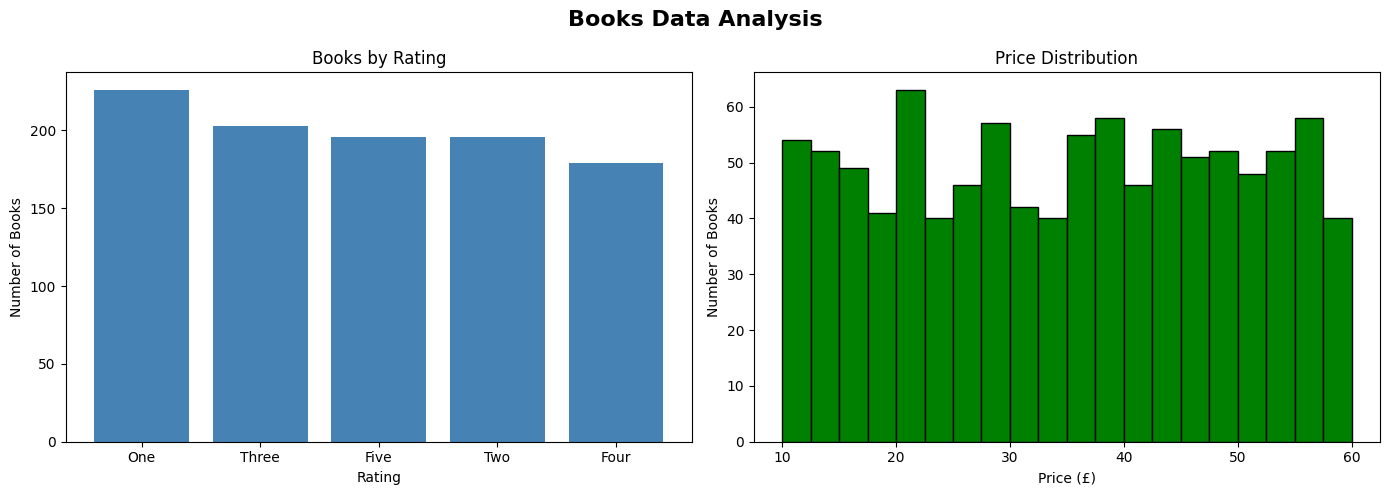

KEY INSIGHTS
1. Total books scraped: 1000
2. Average book price: £35.07
3. Most common rating: One
4. Most expensive book: £59.99
5. Cheapest book: £10.00


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Books Data Analysis', fontsize=16, fontweight='bold')

# Chart 1 - Rating distribution
rating_counts = df_books['Rating'].value_counts()
axes[0].bar(rating_counts.index, rating_counts.values, color='steelblue')
axes[0].set_title('Books by Rating')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Number of Books')

# Chart 2 - Price distribution
axes[1].hist(df_books['Price_Clean'], bins=20, color='green', edgecolor='black')
axes[1].set_title('Price Distribution')
axes[1].set_xlabel('Price (£)')
axes[1].set_ylabel('Number of Books')

plt.tight_layout()
plt.savefig('books_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 50)
print("KEY INSIGHTS")
print("=" * 50)
print(f"1. Total books scraped: {len(df_books)}")
print(f"2. Average book price: £{df_books['Price_Clean'].mean():.2f}")
print(f"3. Most common rating: {df_books['Rating'].value_counts().index[0]}")
print(f"4. Most expensive book: £{df_books['Price_Clean'].max():.2f}")
print(f"5. Cheapest book: £{df_books['Price_Clean'].min():.2f}")
print("=" * 50)